# **Biodiversity Report - ACUS Zamora Chinchipe**

Author: Daning Montaño - Ocampo

Kernel: R

Biodiversity report based on database records

# **1. Packages and libraries**

In [3]:
suppressMessages({
  library(dplyr)
  library(readr)
  library(bdc) ## data cleaning
  library(lubridate)
  library(sf)
  library(ggplot2)
  library(openxlsx)
  library(ggimage)
  source("../functions/themes_nci_zch.R")})

# **2. Load data**

In [4]:
suppressMessages({
bio_records = read.csv( "../../../DATOS/Datasets/Biodiversidad/biodiversidad_ocurrences_clean.csv")#|>
 # filter(coordinateUncertaintyInMeters <= 5000 | is.na(coordinateUncertaintyInMeters))



# Zamora Ch

zamora_ch = st_read("../../../DATOS/SHP/Limites_politicos/Provincia_ZCh.shp")

# ACUS
acus_area = st_read("../../../DATOS/SHP/ACUS/ACUS_ZCH_fix.shp")

# Grids ACUS

grids_acus = st_read("../../../DATOS/SHP/ACUS/ACUS_ZCH_fix.shp")

## IUCN data (global-local)

iucn = read.xlsx("../../../DATOS/Datasets/Biodiversidad/tabla_biodiversidad_ecuador_redlists_all_gbif.xlsx")|>
  select(Estado_conservacion, Endemica, sci_name_gbif)|>
  mutate(scientificName = sci_name_gbif )|>
  select(-sci_name_gbif)
})

Reading layer `Provincia_ZCh' from data source 
  `C:\PROYECTOS\consultorias\ACUS DIAGNOSTICO\DATOS\SHP\Limites_politicos\Provincia_ZCh.shp' 
  using driver `ESRI Shapefile'
Simple feature collection with 1 feature and 7 fields
Geometry type: POLYGON
Dimension:     XY
Bounding box:  xmin: 674165.2 ymin: 9445216 xmax: 792756.4 ymax: 9630431
Projected CRS: WGS 84 / UTM zone 17S
Reading layer `ACUS_ZCH_fix' from data source 
  `C:\PROYECTOS\consultorias\ACUS DIAGNOSTICO\DATOS\SHP\ACUS\ACUS_ZCH_fix.shp' 
  using driver `ESRI Shapefile'
Simple feature collection with 4 features and 2 fields
Geometry type: MULTIPOLYGON
Dimension:     XY
Bounding box:  xmin: 676565.5 ymin: 9445518 xmax: 792737.1 ymax: 9630348
Projected CRS: WGS 84 / UTM zone 17S
Reading layer `ACUS_ZCH_fix' from data source 
  `C:\PROYECTOS\consultorias\ACUS DIAGNOSTICO\DATOS\SHP\ACUS\ACUS_ZCH_fix.shp' 
  using driver `ESRI Shapefile'
Simple feature collection with 4 features and 2 fields
Geometry type: MULTIPOLYGON
Dimension

# **3. Merge with IUCN data**

In [5]:
bio_records_iucn = bio_records |>
  left_join(iucn,  by = c("scientificName"))

Warning message:
In left_join(bio_records, iucn, by = c("scientificName")) :
  Detected an unexpected many-to-many relationship between `x` and `y`.
ℹ Row 1449 of `x` matches multiple rows in `y`.
ℹ Row 7486 of `y` matches multiple rows in `x`.
ℹ If a many-to-many relationship is expected, set `relationship =
  "many-to-many"` to silence this warning.


# **4. Merge data**

In [6]:
# Transform to sf object
bio_records_sf = st_as_sf(
  bio_records_iucn,
  coords = c("decimalLongitude", "decimalLatitude"),
  crs = 4326
) |>
  st_transform(32717)

## **4.1 Zamora Ch.**

In [7]:
recors_zamora_ch <- st_join(
  bio_records_sf,
  zamora_ch %>% select( DPA_DESPRO ),   
  join = st_within                              # inside polygons
)

## **4.2 ACUS**

In [8]:
recors_acus <- st_join(
  bio_records_sf,
  acus_area %>% select( Nombre ),   
  join = st_within                              # inside polygons
)


# **5. Report**

## **5.1 Zamora Ch**

In [7]:
recors_zamora_ch_filter <- recors_zamora_ch %>%
  filter(DPA_DESPRO == "ZAMORA CHINCHIPE") %>%
 # filter(!is.na(Nombre))%>%
  as.data.frame() %>%
  dplyr::filter(
    (kingdom == "Animalia" & class %in% c("Amphibia","Aves","Mammalia","Reptilia","Squamata")) |
    (kingdom == "Plantae")
  ) %>%
  dplyr::mutate(
    Group = dplyr::case_when(
      kingdom == "Plantae" ~ "Plantas",
      class %in% c("Reptilia","Squamata") ~ "Reptiles",
      class == "Amphibia" ~ "Anfibios",
      class == "Aves" ~ "Aves",
      class == "Mammalia" ~ "Mamíferos",
      TRUE ~ NA_character_
    )
  )

head(recors_zamora_ch_filter)

  database_id         scientificName       occurrenceID  eventDate  kingdom
1 BIOWEB_2249   Hyloscirtus diabolus QCAZA60689_SC50389 2015-03-24 Animalia
2 BIOWEB_2251   Hyloscirtus diabolus QCAZA60691_SC50426 2015-03-24 Animalia
3 BIOWEB_2255   Hyloscirtus diabolus QCAZA60695_SC50446 2015-03-24 Animalia
4 BIOWEB_2507 Callimedusa tomopterna QCAZA62995_SC51772 2015-12-18 Animalia
5 BIOWEB_2608      Noblella lochites QCAZA64486_SC51821 2016-04-14 Animalia
6 BIOWEB_2609      Noblella lochites QCAZA64487_SC51830 2016-05-26 Animalia
    phylum    class order       genus specificEpithet collectionID
1 Chordata Amphibia Anura Hyloscirtus        diabolus         <NA>
2 Chordata Amphibia Anura Hyloscirtus        diabolus         <NA>
3 Chordata Amphibia Anura Hyloscirtus        diabolus         <NA>
4 Chordata Amphibia Anura Callimedusa      tomopterna         <NA>
5 Chordata Amphibia Anura    Noblella        lochites         <NA>
6 Chordata Amphibia Anura    Noblella        lochites         <NA>

### Summary

In [8]:
n_sp = length(unique(recors_zamora_ch_filter$scientificName))
n_records = length(recors_zamora_ch_filter$scientificName)
ratio_sp_records = round(n_records/n_sp,0)
cat("Dentro de Zamora Ch. existen un total de: ", n_records, " registros y: ",n_sp, " especies. Por cada especie existen en aproximandame: ", ratio_sp_records)

Dentro de Zamora Ch. existen un total de:  481356  registros y:  8880  especies. Por cada especie existen en aproximandame:  54

### Records by group

In [9]:
records_by_group_zch = recors_zamora_ch_filter %>%
  group_by(Group)%>%
  summarise(Total_records = n())%>%
  arrange(-Total_records)
records_by_group_zch

# A tibble: 5 × 2
  Group     Total_records
  <chr>             <int>
1 Aves             407589
2 Plantas           63814
3 Mamíferos          4555
4 Anfibios           4240
5 Reptiles           1158

In [10]:
icons_plots = c("../Icons/Aves.png", "../Icons/Plantas.png", "../Icons/mamiferos.png", "../Icons/anfibios.png", "../Icons/reptiles.png")
records_by_group_zch$Incons = icons_plots

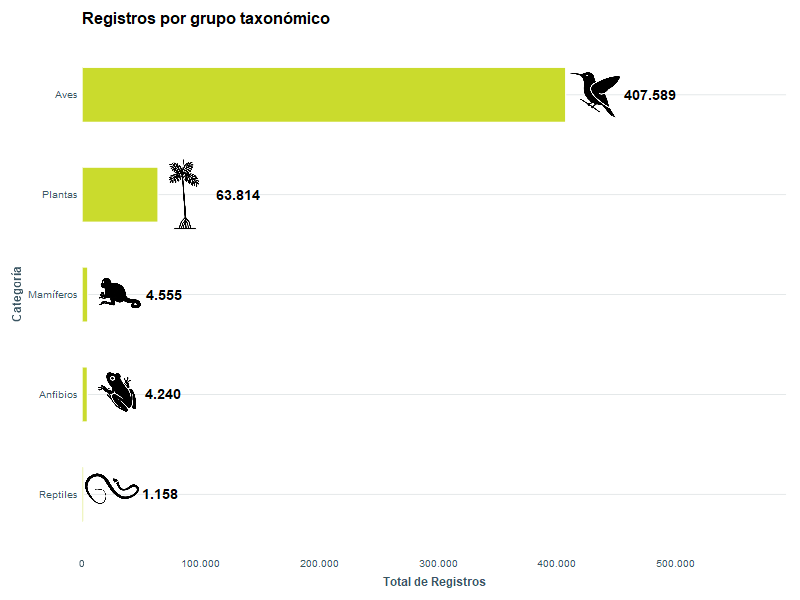

In [11]:
# 1. Calcular un margen dinámico basado en el valor máximo de tus datos
# Esto asegura que la separación sea proporcional al gráfico
max_val <- max(records_by_group_zch$Total_records, na.rm = TRUE)
offset_etiqueta <- max_val * 0.12  # 12% del máximo para el texto
offset_imagen <- max_val * 0.06    # 5% del máximo para el icono

# 2. Crear el gráfico
plot_records_group_zch <- ggplot(records_by_group_zch, aes(x = reorder(Group, Total_records), y = Total_records)) +
  # Barras
  geom_bar(stat = "identity", width = 0.55, fill = pal_zch["verde_lima"], color = "white") +
  
  # IMAGEN: Usamos posición dinámica en 'y' en lugar de nudge fijo
  geom_image(
    aes(y = Total_records + offset_imagen, image = icons_plots),
    size = 0.11, # Ajustado ligeramente para que no sature
    by = "width"
  ) +
  
  # ETIQUETAS: Posición dinámica para que siempre estén a la derecha de la imagen
  geom_text(
    aes(
      y = Total_records + offset_etiqueta, 
      label = scales::number(Total_records, big.mark = ".", decimal.mark = ",")
    ),
    hjust = 0,                   # Alineado a la izquierda desde el punto de inserción
    color = "black",
    fontface = "bold",
    size = 5
  ) +
  
  coord_flip() +
  
  # ESCALA Y: Aumentamos el 'expand' para dar espacio a la derecha
  scale_y_continuous(
    labels = scales::label_number(big.mark = ".", decimal.mark = ","),
    expand = expansion(mult = c(0, 0.3)) # 30% de espacio extra a la derecha
  ) +
  
  labs(
    title = "Registros por grupo taxonómico",
    x = "Categoría",
    y = "Total de Registros"
  ) +
  
  theme_zch() +
  theme(
    panel.grid.major.x = element_blank(),
    legend.position = "none"
  )

# Visualizar
plot_records_group_zch

In [12]:
# Exportación en milímetros (mm)
ggsave(
  filename = "../Results/Zch/Records_ZCH.png", 
  plot = plot_records_group_zch, 
  device = "png",
  width = 165,               # Ancho en mm
  height = 130,              # Alto en mm
  units = "mm",              # <--- DEFINIR LA UNIDAD AQUÍ
  dpi = 600,                 # Resolución para impresión/calidad
  bg = "white"               # Fondo blanco institucional
)

### Species by group

In [13]:
sp_by_group_zch = recors_zamora_ch_filter %>%
  group_by(Group)%>%
  distinct(scientificName)%>%
  summarise(Total_sp = n())%>%
  arrange(-Total_sp)
sp_by_group_zch

# A tibble: 5 × 2
  Group     Total_sp
  <chr>        <int>
1 Plantas       7387
2 Aves          1036
3 Anfibios       195
4 Mamíferos      144
5 Reptiles       118

In [14]:
icons_plots = c("../Icons/Plantas.png", "../Icons/Aves.png", "../Icons/anfibios.png", "../Icons/mamiferos.png", "../Icons/reptiles.png")
sp_by_group_zch$Incons = icons_plots

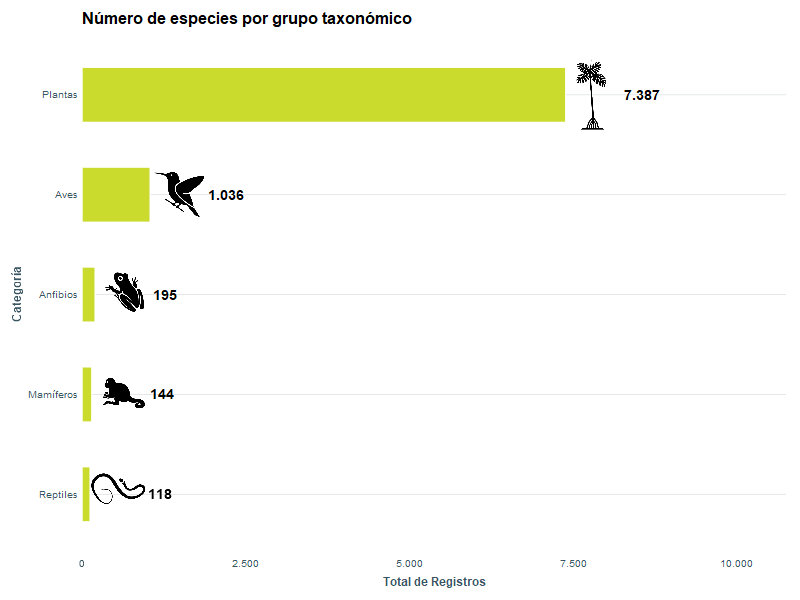

In [15]:
# 1. Calcular un margen dinámico basado en el valor máximo de tus datos
# Esto asegura que la separación sea proporcional al gráfico
max_val <- max(sp_by_group_zch$Total_sp, na.rm = TRUE)
offset_etiqueta <- max_val * 0.12  # 12% del máximo para el texto
offset_imagen <- max_val * 0.06    # 5% del máximo para el icono

# 2. Crear el gráfico
plot_sp_group_zch <- ggplot(sp_by_group_zch, aes(x = reorder(Group, Total_sp), y = Total_sp)) +
  # Barras
  geom_bar(stat = "identity", width = 0.55, fill = pal_zch["verde_lima"], color = "white") +
  
  # IMAGEN: Usamos posición dinámica en 'y' en lugar de nudge fijo
  geom_image(
    aes(y = Total_sp + offset_imagen, image = icons_plots),
    size = 0.11, # Ajustado ligeramente para que no sature
    by = "width"
  ) +
  
  # ETIQUETAS: Posición dinámica para que siempre estén a la derecha de la imagen
  geom_text(
    aes(
      y = Total_sp + offset_etiqueta, 
      label = scales::number(Total_sp, big.mark = ".", decimal.mark = ",")
    ),
    hjust = 0,                   # Alineado a la izquierda desde el punto de inserción
    color = "black",
    fontface = "bold",
    size = 5
  ) +
  
  coord_flip() +
  
  # ESCALA Y: Aumentamos el 'expand' para dar espacio a la derecha
  scale_y_continuous(
    labels = scales::label_number(big.mark = ".", decimal.mark = ","),
    expand = expansion(mult = c(0, 0.3)) # 30% de espacio extra a la derecha
  ) +
  
  labs(
    title = "Número de especies por grupo taxonómico",
    x = "Categoría",
    y = "Total de Registros"
  ) +
  
  theme_zch() +
  theme(
    panel.grid.major.x = element_blank(),
    legend.position = "none"
  )

# Visualizar
plot_sp_group_zch

In [16]:
# Exportación en milímetros (mm)
ggsave(
  filename = "../Results/Zch/Sp_ZCH.png", 
  plot = plot_sp_group_zch, 
  device = "png",
  width = 165,               # Ancho en mm
  height = 130,              # Alto en mm
  units = "mm",              # <--- DEFINIR LA UNIDAD AQUÍ
  dpi = 600,                 # Resolución para impresión/calidad
  bg = "white"               # Fondo blanco institucional
)

### Red list

In [17]:
sp_by_group_redlist_zch = recors_zamora_ch_filter %>%
  #filter(!is.na(Estado_conservacion))%>%
  filter(Estado_conservacion %in% c("VU" ,"EN" , "CR"))%>%
  group_by(Group,Estado_conservacion)%>%
  distinct(scientificName)%>%
  summarise(Total_sp = n())
sp_by_group_redlist_zch

`summarise()` has grouped output by 'Group'. You can override using the
`.groups` argument.


# A tibble: 14 × 3
# Groups:   Group [5]
   Group     Estado_conservacion Total_sp
   <chr>     <chr>                  <int>
 1 Anfibios  CR                         8
 2 Anfibios  EN                        31
 3 Anfibios  VU                        38
 4 Aves      CR                         3
 5 Aves      EN                        16
 6 Aves      VU                        35
 7 Mamíferos CR                         1
 8 Mamíferos EN                         9
 9 Mamíferos VU                        12
10 Plantas   CR                        26
11 Plantas   EN                       179
12 Plantas   VU                       414
13 Reptiles  EN                         2
14 Reptiles  VU                         4

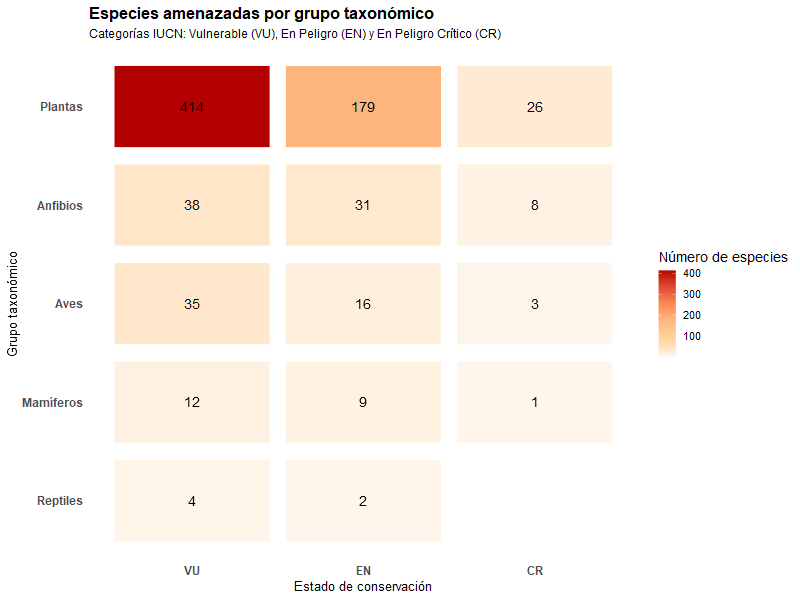

In [18]:


# =========================================================
# 1. Ordenar grupos por total de especies amenazadas
# =========================================================
orden_grupos <- sp_by_group_redlist_zch %>%
  group_by(Group) %>%
  summarise(total = sum(Total_sp), .groups = "drop") %>%
  arrange(total) %>%
  pull(Group)

sp_plot <- sp_by_group_redlist_zch %>%
  mutate(
    Group = factor(Group, levels = orden_grupos),
    Estado_conservacion = factor(
      Estado_conservacion,
      levels = c("VU", "EN", "CR")
    )
  )

# =========================================================
# 2. Heatmap con escala rojo-naranja
# =========================================================
plot_redlist_heatmap <- ggplot(
  sp_plot,
  aes(x = Estado_conservacion, y = Group, fill = Total_sp)
) +
  geom_tile(
    color = "white",
    linewidth = 1.2,
    width = 0.92,
    height = 0.85
  ) +
  geom_text(
    aes(label = number(Total_sp, big.mark = ".", decimal.mark = ",")),
    color = "black",
    size = 5
  ) +
  scale_fill_gradientn(
    colours = c("#fff5eb", "#fdd49e", "#fdbb84", "#fc8d59", "#e34a33", "#b30000"),
    labels = label_number(big.mark = ".", decimal.mark = ",")
  ) +
  labs(
    title = "Especies amenazadas por grupo taxonómico",
    subtitle = "Categorías IUCN: Vulnerable (VU), En Peligro (EN) y En Peligro Crítico (CR)",
    x = "Estado de conservación",
    y = "Grupo taxonómico",
    fill = "Número de especies"
  ) +
  theme_minimal(base_size = 14) +
  theme(
    panel.grid = element_blank(),
    axis.title.x = element_text(size = 13),
    axis.title.y = element_text(size = 13),
    axis.text.x = element_text(size = 12, face = "bold"),
    axis.text.y = element_text(size = 12, face = "bold"),
    legend.position = "right",
    plot.title = element_text(size = 16, face = "bold"),
    plot.subtitle = element_text(size = 12)
  )

plot_redlist_heatmap

### Red list - last 10 years

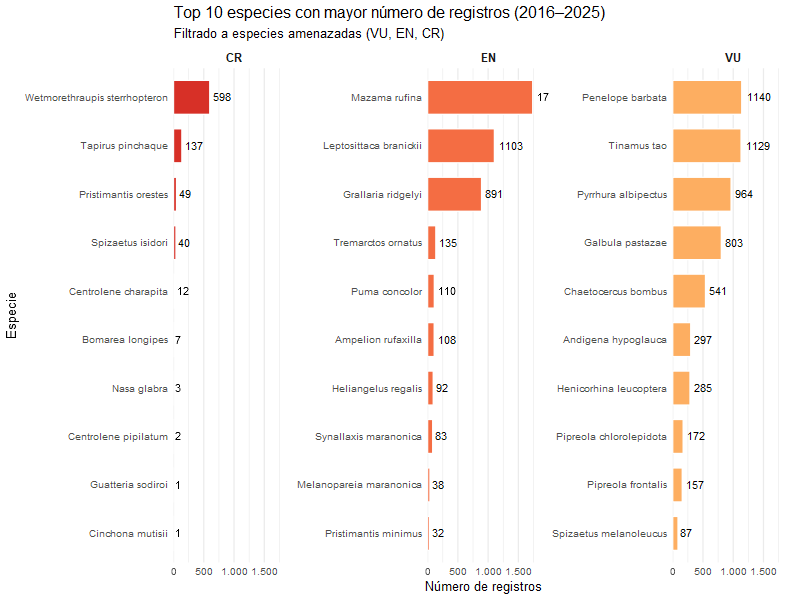

In [19]:

# =========================================================
# 1. Filtrar años y categorías de amenaza
# =========================================================
df_filtrado <- recors_zamora_ch_filter %>%
  mutate(
    year = as.numeric(year),
    Estado_conservacion = as.character(Estado_conservacion)
  ) %>%
  filter(
    year >= 2016 & year <= 2025,
    Estado_conservacion %in% c("VU", "EN", "CR"),
    !is.na(scientificName)
  )

# =========================================================
# 2. Conteo de ocurrencias por especie + categoría
# =========================================================
sp_count <- df_filtrado %>%
  group_by(scientificName, Estado_conservacion) %>%
  summarise(
    n_registros = n(),
    .groups = "drop"
  )

# =========================================================
# 3. Top 10 por categoría
# =========================================================
top_sp <- sp_count %>%
  group_by(Estado_conservacion) %>%
  slice_max(order_by = n_registros, n = 10, with_ties = FALSE) %>%
  ungroup()

# =========================================================
# 4. Orden interno por faceta
# =========================================================
top_sp <- top_sp %>%
  group_by(Estado_conservacion) %>%
  mutate(
    scientificName = reorder(scientificName, n_registros)
  ) %>%
  ungroup()

# =========================================================
# 5. Paleta consistente con riesgo
# =========================================================
pal_redlist <- c(
  "VU" = "#fdae61",
  "EN" = "#f46d43",
  "CR" = "#d73027"
)

# =========================================================
# 6. Gráfico final (facet + barras horizontales)
# =========================================================
plot_top_species <- ggplot(
  top_sp,
  aes(x = scientificName, y = n_registros, fill = Estado_conservacion)
) +
  
  geom_col(width = 0.7, color = "white") +
  
  geom_text(
    aes(label = n_registros),
    hjust = -0.2,
    size = 3.8
  ) +
  
  coord_flip() +
  
  facet_wrap(~Estado_conservacion, scales = "free_y") +
  
  scale_fill_manual(values = pal_redlist) +
  
  scale_y_continuous(
    labels = label_number(big.mark = ".", decimal.mark = ","),
    expand = expansion(mult = c(0, 0.15))
  ) +
  
  labs(
    title = "Top 10 especies con mayor número de registros (2016–2025)",
    subtitle = "Filtrado a especies amenazadas (VU, EN, CR)",
    x = "Especie",
    y = "Número de registros"
  ) +
  
  theme_minimal(base_size = 13) +
  theme(
    strip.text = element_text(size = 12, face = "bold"),
    panel.grid.major.y = element_blank(),
    legend.position = "none"
  )

plot_top_species

### Red list - Temporal assessment of threatened species

In [20]:
library(dplyr)
library(lubridate)

# =========================================================
# 1. Preparación
# =========================================================
df <- recors_zamora_ch_filter %>%
  mutate(
    eventDate = as.Date(eventDate),
    year = year(eventDate),
    month = month(eventDate)
  ) %>%
  filter(
    !is.na(scientificName),
    Estado_conservacion %in% c("VU", "EN", "CR"),
    !is.na(Group),
    !is.na(eventDate)
  )

# =========================================================
# 2. Presencia base (10 años)
# Presencia si la especie tuvo al menos un registro
# independiente en algún mes de los últimos 10 años
# =========================================================
base_10y <- df %>%
  filter(year >= (max(year, na.rm = TRUE) - 9)) %>%
  distinct(scientificName, Estado_conservacion, Group, year, month) %>%
  distinct(scientificName, Estado_conservacion, Group) %>%
  mutate(presencia_10y = 1)

# =========================================================
# 3. Vigencia (5 años)
# Presencia si la especie tuvo al menos un registro
# independiente en algún mes de los últimos 5 años
# =========================================================
vigencia_5y <- df %>%
  filter(year >= (max(year, na.rm = TRUE) - 4)) %>%
  distinct(scientificName, Estado_conservacion, Group, year, month) %>%
  distinct(scientificName, Estado_conservacion, Group) %>%
  mutate(presencia_5y = 1)

# =========================================================
# 4. Conteo de registros independientes por mes
# en los últimos 5 años
# Si hay 5 registros en el mismo mes-año, cuenta como 1
# =========================================================
registros_5y <- df %>%
  filter(year >= (max(year, na.rm = TRUE) - 4)) %>%
  distinct(scientificName, Estado_conservacion, Group, year, month) %>%
  group_by(scientificName, Estado_conservacion, Group) %>%
  summarise(
    total_registros_5y = n(),
    .groups = "drop"
  )

# =========================================================
# 5. Integración
# =========================================================
estado_sp <- full_join(
  base_10y,
  vigencia_5y,
  by = c("scientificName", "Estado_conservacion", "Group")
) %>%
  mutate(
    presencia_10y = ifelse(is.na(presencia_10y), 0, presencia_10y),
    presencia_5y  = ifelse(is.na(presencia_5y), 0, presencia_5y)
  ) %>%
  left_join(
    registros_5y,
    by = c("scientificName", "Estado_conservacion", "Group")
  ) %>%
  mutate(
    total_registros_5y = ifelse(is.na(total_registros_5y), 0, total_registros_5y)
  )

# =========================================================
# 6. Clasificación diagnóstica
# =========================================================
estado_sp <- estado_sp %>%
  mutate(
    estado_diagnostico = case_when(
      presencia_10y == 1 & presencia_5y == 1 ~ "Confirmada y vigente",
      presencia_10y == 1 & presencia_5y == 0 ~ "Alerta (sin registros recientes)",
      presencia_10y == 0 ~ "Sin evidencia reciente"
    )
  )


Summary

In [21]:
# =========================================================
# 7. Resumen final (solo conteo de especies por categoría)
# =========================================================
resumen_estado <- estado_sp %>%
  group_by(Estado_conservacion, estado_diagnostico) %>%
  summarise(
    n_especies = n_distinct(scientificName),
    .groups = "drop"
  )

resumen_estado

# A tibble: 6 × 3
  Estado_conservacion estado_diagnostico               n_especies
  <chr>               <chr>                                 <int>
1 CR                  Alerta (sin registros recientes)          6
2 CR                  Confirmada y vigente                      8
3 EN                  Alerta (sin registros recientes)         37
4 EN                  Confirmada y vigente                     52
5 VU                  Alerta (sin registros recientes)         60
6 VU                  Confirmada y vigente                    112

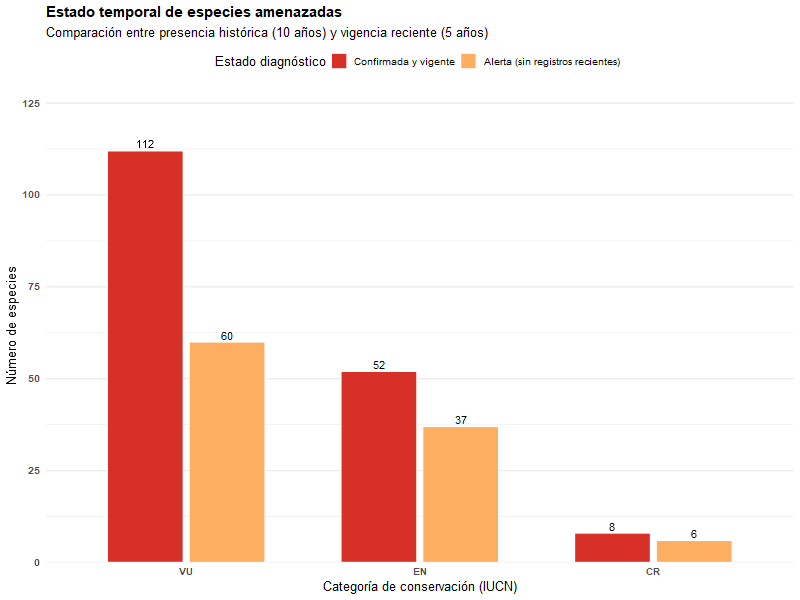

In [22]:


# =========================================================
# 1. Ordenar factores
# =========================================================
resumen_estado <- resumen_estado %>%
  mutate(
    Estado_conservacion = factor(Estado_conservacion, levels = c("VU", "EN", "CR")),
    estado_diagnostico = factor(
      estado_diagnostico,
      levels = c(
        "Confirmada y vigente",
        "Alerta (sin registros recientes)",
        "Sin evidencia reciente"
      )
    )
  )

# =========================================================
# 2. Paleta coherente con diagnóstico
# =========================================================
pal_estado <- c(
  "Confirmada y vigente" = "#d73027",   # azul (estable)
  "Alerta (sin registros recientes)" = "#fdae61",  # rojo (alerta)
  "Sin evidencia reciente" = "#bdbdbd"  # gris (incertidumbre)
)

# =========================================================
# 3. Gráfico
# =========================================================
plot_resumen_estado <- ggplot(
  resumen_estado,
  aes(x = Estado_conservacion, y = n_especies, fill = estado_diagnostico)
) +
  
  geom_col(
    position = position_dodge(width = 0.7),
    width = 0.65,
    color = "white"
  ) +
  
  geom_text(
    aes(label = n_especies),
    position = position_dodge(width = 0.7),
    vjust = -0.3,
    size = 4
  ) +
  
  scale_fill_manual(values = pal_estado) +
  
  scale_y_continuous(
    labels = label_number(big.mark = ".", decimal.mark = ","),
    expand = expansion(mult = c(0, 0.15))
  ) +
  
  labs(
    title = "Estado temporal de especies amenazadas",
    subtitle = "Comparación entre presencia histórica (10 años) y vigencia reciente (5 años)",
    x = "Categoría de conservación (IUCN)",
    y = "Número de especies",
    fill = "Estado diagnóstico"
  ) +
  
  theme_minimal(base_size = 13) +
  theme(
    panel.grid.major.x = element_blank(),
    legend.position = "top",
    axis.text = element_text(face = "bold"),
    plot.title = element_text(size = 15, face = "bold")
  )

plot_resumen_estado

## 5.2 ACUS

In [23]:
recors_acus_filter <- recors_acus %>%
  filter(!is.na(Nombre)) %>%
 # filter(!is.na(Nombre))%>%
  as.data.frame() %>%
  dplyr::filter(
    (kingdom == "Animalia" & class %in% c("Amphibia","Aves","Mammalia","Reptilia","Squamata")) |
    (kingdom == "Plantae")
  ) %>%
  dplyr::mutate(
    Group = dplyr::case_when(
      kingdom == "Plantae" ~ "Plantas",
      class %in% c("Reptilia","Squamata") ~ "Reptiles",
      class == "Amphibia" ~ "Anfibios",
      class == "Aves" ~ "Aves",
      class == "Mammalia" ~ "Mamíferos",
      TRUE ~ NA_character_
    )
  )

head(recors_acus_filter)

    database_id          scientificName       occurrenceID  eventDate  kingdom
367 BIOWEB_2608       Noblella lochites QCAZA64486_SC51821 2016-04-14 Animalia
393 BIOWEB_2638 Callimedusa ecuatoriana QCAZA64963_SC56684 2016-10-01 Animalia
394 BIOWEB_2639 Callimedusa ecuatoriana QCAZA64964_SC56684 2016-10-01 Animalia
395 BIOWEB_2640 Callimedusa ecuatoriana QCAZA64965_SC56684 2016-10-01 Animalia
398 BIOWEB_2644 Callimedusa ecuatoriana QCAZA64998_SC56684 2016-10-01 Animalia
469 BIOWEB_2728    Hyloscirtus diabolus QCAZA65246_SC56685 2016-10-01 Animalia
      phylum    class order       genus specificEpithet collectionID
367 Chordata Amphibia Anura    Noblella        lochites         <NA>
393 Chordata Amphibia Anura Callimedusa     ecuatoriana         <NA>
394 Chordata Amphibia Anura Callimedusa     ecuatoriana         <NA>
395 Chordata Amphibia Anura Callimedusa     ecuatoriana         <NA>
398 Chordata Amphibia Anura Callimedusa     ecuatoriana         <NA>
469 Chordata Amphibia Anura Hylos

### Records by group

In [24]:
records_by_group_acus= recors_acus_filter %>%
  group_by(Group)%>%
  summarise(Total_records = n())%>%
  arrange(-Total_records)
records_by_group_acus

# A tibble: 5 × 2
  Group     Total_records
  <chr>             <int>
1 Aves             108563
2 Plantas           31259
3 Mamíferos          2790
4 Anfibios           1519
5 Reptiles            350

In [25]:
icons_plots = c("../Icons/Aves.png", "../Icons/Plantas.png", "../Icons/mamiferos.png", "../Icons/anfibios.png", "../Icons/reptiles.png")
records_by_group_acus$Incons = icons_plots

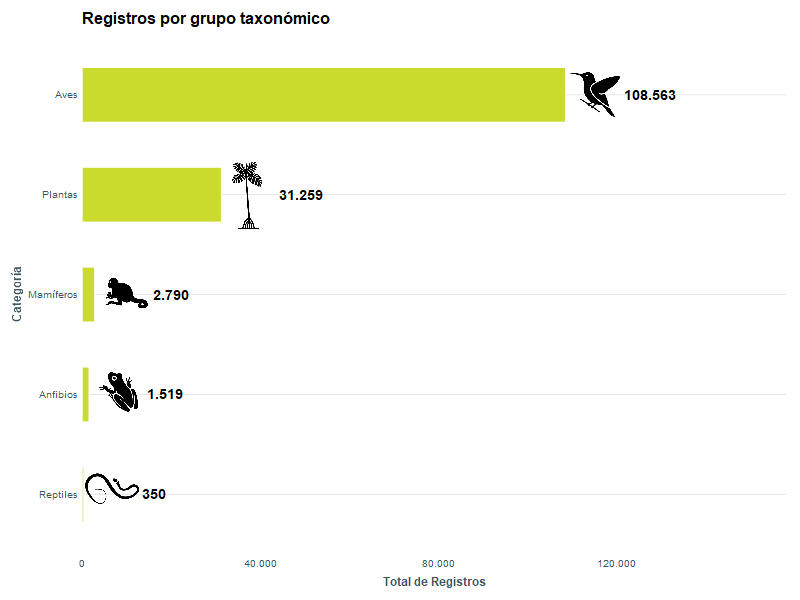

In [26]:
# 1. Calcular un margen dinámico basado en el valor máximo de tus datos
# Esto asegura que la separación sea proporcional al gráfico
max_val <- max(records_by_group_acus$Total_records, na.rm = TRUE)
offset_etiqueta <- max_val * 0.12  # 12% del máximo para el texto
offset_imagen <- max_val * 0.06    # 5% del máximo para el icono

# 2. Crear el gráfico
plot_records_group_acus<- ggplot(records_by_group_acus, aes(x = reorder(Group, Total_records), y = Total_records)) +
  # Barras
  geom_bar(stat = "identity", width = 0.55, fill = pal_zch["verde_lima"], color = "white") +
  
  # IMAGEN: Usamos posición dinámica en 'y' en lugar de nudge fijo
  geom_image(
    aes(y = Total_records + offset_imagen, image = icons_plots),
    size = 0.11, # Ajustado ligeramente para que no sature
    by = "width"
  ) +
  
  # ETIQUETAS: Posición dinámica para que siempre estén a la derecha de la imagen
  geom_text(
    aes(
      y = Total_records + offset_etiqueta, 
      label = scales::number(Total_records, big.mark = ".", decimal.mark = ",")
    ),
    hjust = 0,                   # Alineado a la izquierda desde el punto de inserción
    color = "black",
    fontface = "bold",
    size = 5
  ) +
  
  coord_flip() +
  
  # ESCALA Y: Aumentamos el 'expand' para dar espacio a la derecha
  scale_y_continuous(
    labels = scales::label_number(big.mark = ".", decimal.mark = ","),
    expand = expansion(mult = c(0, 0.3)) # 30% de espacio extra a la derecha
  ) +
  
  labs(
    title = "Registros por grupo taxonómico",
    x = "Categoría",
    y = "Total de Registros"
  ) +
  
  theme_zch() +
  theme(
    panel.grid.major.x = element_blank(),
    legend.position = "none"
  )

# Visualizar
plot_records_group_acus

### Species by group

In [27]:
sp_by_group_acus= recors_acus_filter %>%
  group_by(Group)%>%
  distinct(scientificName)%>%
  summarise(Total_sp = n())%>%
  arrange(-Total_sp)
sp_by_group_acus

# A tibble: 5 × 2
  Group     Total_sp
  <chr>        <int>
1 Plantas       4717
2 Aves           836
3 Anfibios       139
4 Mamíferos       83
5 Reptiles        68

In [28]:
icons_plots = c("../Icons/Plantas.png", "../Icons/Aves.png", "../Icons/anfibios.png", "../Icons/mamiferos.png", "../Icons/reptiles.png")
sp_by_group_acus$Incons = icons_plots

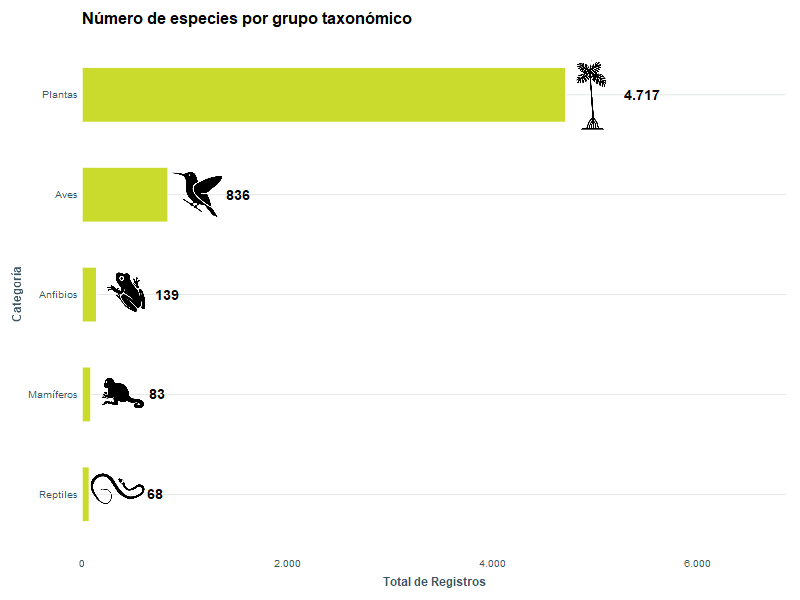

In [29]:
# 1. Calcular un margen dinámico basado en el valor máximo de tus datos
# Esto asegura que la separación sea proporcional al gráfico
max_val <- max(sp_by_group_acus$Total_sp, na.rm = TRUE)
offset_etiqueta <- max_val * 0.12  # 12% del máximo para el texto
offset_imagen <- max_val * 0.06    # 5% del máximo para el icono

# 2. Crear el gráfico
plot_sp_group_acus<- ggplot(sp_by_group_acus, aes(x = reorder(Group, Total_sp), y = Total_sp)) +
  # Barras
  geom_bar(stat = "identity", width = 0.55, fill = pal_zch["verde_lima"], color = "white") +
  
  # IMAGEN: Usamos posición dinámica en 'y' en lugar de nudge fijo
  geom_image(
    aes(y = Total_sp + offset_imagen, image = icons_plots),
    size = 0.11, # Ajustado ligeramente para que no sature
    by = "width"
  ) +
  
  # ETIQUETAS: Posición dinámica para que siempre estén a la derecha de la imagen
  geom_text(
    aes(
      y = Total_sp + offset_etiqueta, 
      label = scales::number(Total_sp, big.mark = ".", decimal.mark = ",")
    ),
    hjust = 0,                   # Alineado a la izquierda desde el punto de inserción
    color = "black",
    fontface = "bold",
    size = 5
  ) +
  
  coord_flip() +
  
  # ESCALA Y: Aumentamos el 'expand' para dar espacio a la derecha
  scale_y_continuous(
    labels = scales::label_number(big.mark = ".", decimal.mark = ","),
    expand = expansion(mult = c(0, 0.3)) # 30% de espacio extra a la derecha
  ) +
  
  labs(
    title = "Número de especies por grupo taxonómico",
    x = "Categoría",
    y = "Total de Registros"
  ) +
  
  theme_zch() +
  theme(
    panel.grid.major.x = element_blank(),
    legend.position = "none"
  )

# Visualizar
plot_sp_group_acus

### Red list

In [30]:
sp_by_group_redlist_acus = recors_acus_filter %>%
  #filter(!is.na(Estado_conservacion))%>%
  filter(Estado_conservacion %in% c("VU" ,"EN" , "CR"))%>%
  group_by(Group,Estado_conservacion)%>%
  distinct(scientificName)%>%
  summarise(Total_sp = n())
sp_by_group_redlist_acus

`summarise()` has grouped output by 'Group'. You can override using the
`.groups` argument.


# A tibble: 14 × 3
# Groups:   Group [5]
   Group     Estado_conservacion Total_sp
   <chr>     <chr>                  <int>
 1 Anfibios  CR                         5
 2 Anfibios  EN                        22
 3 Anfibios  VU                        24
 4 Aves      CR                         2
 5 Aves      EN                        12
 6 Aves      VU                        22
 7 Mamíferos CR                         1
 8 Mamíferos EN                         6
 9 Mamíferos VU                         9
10 Plantas   CR                        20
11 Plantas   EN                        93
12 Plantas   VU                       254
13 Reptiles  EN                         2
14 Reptiles  VU                         1

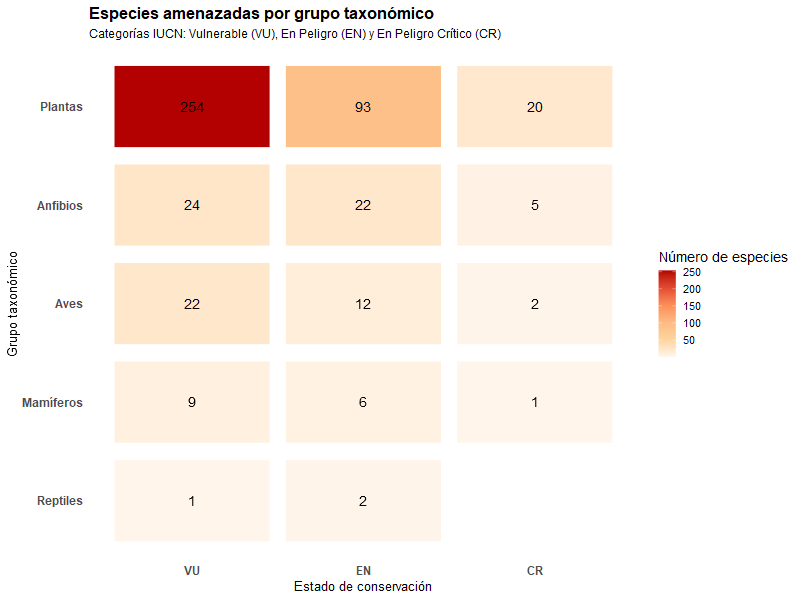

In [31]:


# =========================================================
# 1. Ordenar grupos por total de especies amenazadas
# =========================================================
orden_grupos <- sp_by_group_redlist_acus %>%
  group_by(Group) %>%
  summarise(total = sum(Total_sp), .groups = "drop") %>%
  arrange(total) %>%
  pull(Group)

sp_plot <- sp_by_group_redlist_acus %>%
  mutate(
    Group = factor(Group, levels = orden_grupos),
    Estado_conservacion = factor(
      Estado_conservacion,
      levels = c("VU", "EN", "CR")
    )
  )

# =========================================================
# 2. Heatmap con escala rojo-naranja
# =========================================================
plot_redlist_heatmap_acus <- ggplot(
  sp_plot,
  aes(x = Estado_conservacion, y = Group, fill = Total_sp)
) +
  geom_tile(
    color = "white",
    linewidth = 1.2,
    width = 0.92,
    height = 0.85
  ) +
  geom_text(
    aes(label = number(Total_sp, big.mark = ".", decimal.mark = ",")),
    color = "black",
    size = 5
  ) +
  scale_fill_gradientn(
    colours = c("#fff5eb", "#fdd49e", "#fdbb84", "#fc8d59", "#e34a33", "#b30000"),
    labels = label_number(big.mark = ".", decimal.mark = ",")
  ) +
  labs(
    title = "Especies amenazadas por grupo taxonómico",
    subtitle = "Categorías IUCN: Vulnerable (VU), En Peligro (EN) y En Peligro Crítico (CR)",
    x = "Estado de conservación",
    y = "Grupo taxonómico",
    fill = "Número de especies"
  ) +
  theme_minimal(base_size = 14) +
  theme(
    panel.grid = element_blank(),
    axis.title.x = element_text(size = 13),
    axis.title.y = element_text(size = 13),
    axis.text.x = element_text(size = 12, face = "bold"),
    axis.text.y = element_text(size = 12, face = "bold"),
    legend.position = "right",
    plot.title = element_text(size = 16, face = "bold"),
    plot.subtitle = element_text(size = 12)
  )

plot_redlist_heatmap_acus

### Red list - last 10 years

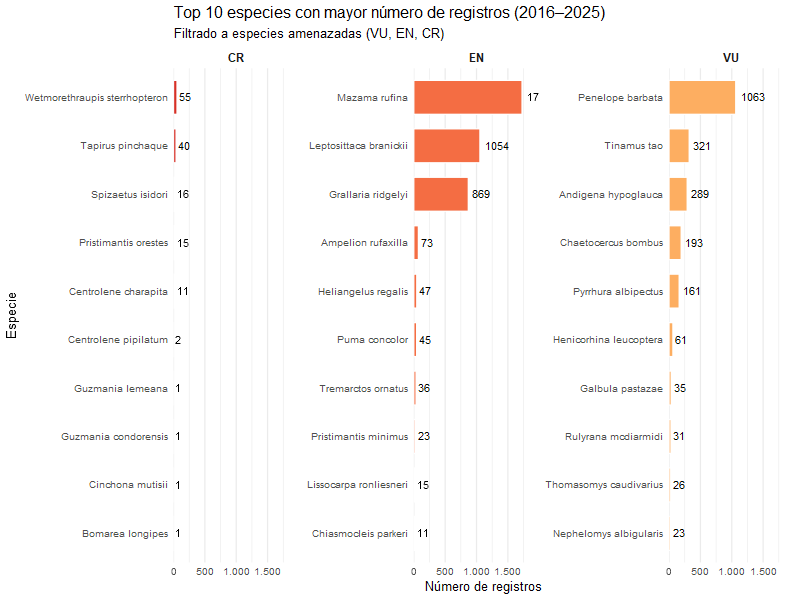

In [32]:

# =========================================================
# 1. Filtrar años y categorías de amenaza
# =========================================================
df_filtrado <- recors_acus_filter %>%
  mutate(
    year = as.numeric(year),
    Estado_conservacion = as.character(Estado_conservacion)
  ) %>%
  filter(
    year >= 2016 & year <= 2025,
    Estado_conservacion %in% c("VU", "EN", "CR"),
    !is.na(scientificName)
  )

# =========================================================
# 2. Conteo de ocurrencias por especie + categoría
# =========================================================
sp_count <- df_filtrado %>%
  group_by(scientificName, Estado_conservacion) %>%
  summarise(
    n_registros = n(),
    .groups = "drop"
  )

# =========================================================
# 3. Top 10 por categoría
# =========================================================
top_sp <- sp_count %>%
  group_by(Estado_conservacion) %>%
  slice_max(order_by = n_registros, n = 10, with_ties = FALSE) %>%
  ungroup()

# =========================================================
# 4. Orden interno por faceta
# =========================================================
top_sp <- top_sp %>%
  group_by(Estado_conservacion) %>%
  mutate(
    scientificName = reorder(scientificName, n_registros)
  ) %>%
  ungroup()

# =========================================================
# 5. Paleta consistente con riesgo
# =========================================================
pal_redlist <- c(
  "VU" = "#fdae61",
  "EN" = "#f46d43",
  "CR" = "#d73027"
)

# =========================================================
# 6. Gráfico final (facet + barras horizontales)
# =========================================================
plot_top_species_acus <- ggplot(
  top_sp,
  aes(x = scientificName, y = n_registros, fill = Estado_conservacion)
) +
  
  geom_col(width = 0.7, color = "white") +
  
  geom_text(
    aes(label = n_registros),
    hjust = -0.2,
    size = 3.8
  ) +
  
  coord_flip() +
  
  facet_wrap(~Estado_conservacion, scales = "free_y") +
  
  scale_fill_manual(values = pal_redlist) +
  
  scale_y_continuous(
    labels = label_number(big.mark = ".", decimal.mark = ","),
    expand = expansion(mult = c(0, 0.15))
  ) +
  
  labs(
    title = "Top 10 especies con mayor número de registros (2016–2025)",
    subtitle = "Filtrado a especies amenazadas (VU, EN, CR)",
    x = "Especie",
    y = "Número de registros"
  ) +
  
  theme_minimal(base_size = 13) +
  theme(
    strip.text = element_text(size = 12, face = "bold"),
    panel.grid.major.y = element_blank(),
    legend.position = "none"
  )

  plot_top_species_acus

### Red list - Temporal assessment of threatened species

In [33]:
library(dplyr)
library(lubridate)

# =========================================================
# 1. Preparación
# =========================================================
df <- recors_acus_filter %>%
  mutate(
    eventDate = as.Date(eventDate),
    year = year(eventDate),
    month = month(eventDate)
  ) %>%
  filter(
    !is.na(scientificName),
    Estado_conservacion %in% c("VU", "EN", "CR"),
    !is.na(Group),
    !is.na(eventDate)
  )

# =========================================================
# 2. Presencia base (10 años)
# Presencia si la especie tuvo al menos un registro
# independiente en algún mes de los últimos 10 años
# =========================================================
base_10y <- df %>%
  filter(year >= (max(year, na.rm = TRUE) - 9)) %>%
  distinct(scientificName, Estado_conservacion, Group, year, month) %>%
  distinct(scientificName, Estado_conservacion, Group) %>%
  mutate(presencia_10y = 1)

# =========================================================
# 3. Vigencia (5 años)
# Presencia si la especie tuvo al menos un registro
# independiente en algún mes de los últimos 5 años
# =========================================================
vigencia_5y <- df %>%
  filter(year >= (max(year, na.rm = TRUE) - 4)) %>%
  distinct(scientificName, Estado_conservacion, Group, year, month) %>%
  distinct(scientificName, Estado_conservacion, Group) %>%
  mutate(presencia_5y = 1)

# =========================================================
# 4. Conteo de registros independientes por mes
# en los últimos 5 años
# Si hay 5 registros en el mismo mes-año, cuenta como 1
# =========================================================
registros_5y <- df %>%
  filter(year >= (max(year, na.rm = TRUE) - 4)) %>%
  distinct(scientificName, Estado_conservacion, Group, year, month) %>%
  group_by(scientificName, Estado_conservacion, Group) %>%
  summarise(
    total_registros_5y = n(),
    .groups = "drop"
  )

# =========================================================
# 5. Integración
# =========================================================
estado_sp <- full_join(
  base_10y,
  vigencia_5y,
  by = c("scientificName", "Estado_conservacion", "Group")
) %>%
  mutate(
    presencia_10y = ifelse(is.na(presencia_10y), 0, presencia_10y),
    presencia_5y  = ifelse(is.na(presencia_5y), 0, presencia_5y)
  ) %>%
  left_join(
    registros_5y,
    by = c("scientificName", "Estado_conservacion", "Group")
  ) %>%
  mutate(
    total_registros_5y = ifelse(is.na(total_registros_5y), 0, total_registros_5y)
  )

# =========================================================
# 6. Clasificación diagnóstica
# =========================================================
estado_sp <- estado_sp %>%
  mutate(
    estado_diagnostico = case_when(
      presencia_10y == 1 & presencia_5y == 1 ~ "Confirmada y vigente",
      presencia_10y == 1 & presencia_5y == 0 ~ "Alerta (sin registros recientes)",
      presencia_10y == 0 ~ "Sin evidencia reciente"
    )
  )

Summary

In [34]:
# =========================================================
# 7. Resumen final (solo conteo de especies por categoría)
# =========================================================
resumen_estado <- estado_sp %>%
  group_by(Estado_conservacion, estado_diagnostico) %>%
  summarise(
    n_especies = n_distinct(scientificName),
    .groups = "drop"
  )

resumen_estado

# A tibble: 6 × 3
  Estado_conservacion estado_diagnostico               n_especies
  <chr>               <chr>                                 <int>
1 CR                  Alerta (sin registros recientes)          6
2 CR                  Confirmada y vigente                      6
3 EN                  Alerta (sin registros recientes)         24
4 EN                  Confirmada y vigente                     29
5 VU                  Alerta (sin registros recientes)         35
6 VU                  Confirmada y vigente                     62

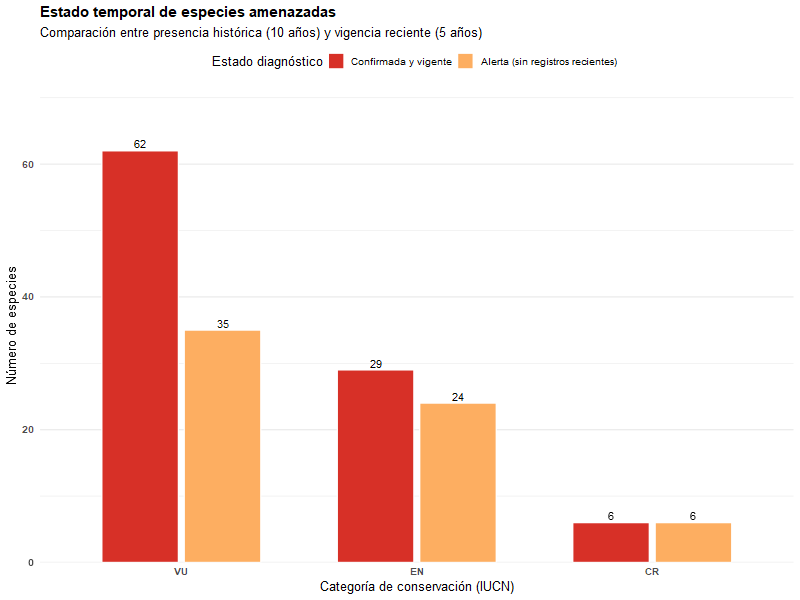

In [35]:


# =========================================================
# 1. Ordenar factores
# =========================================================
resumen_estado <- resumen_estado %>%
  mutate(
    Estado_conservacion = factor(Estado_conservacion, levels = c("VU", "EN", "CR")),
    estado_diagnostico = factor(
      estado_diagnostico,
      levels = c(
        "Confirmada y vigente",
        "Alerta (sin registros recientes)",
        "Sin evidencia reciente"
      )
    )
  )

# =========================================================
# 2. Paleta coherente con diagnóstico
# =========================================================
pal_estado <- c(
  "Confirmada y vigente" = "#d73027",   # azul (estable)
  "Alerta (sin registros recientes)" = "#fdae61",  # rojo (alerta)
  "Sin evidencia reciente" = "#bdbdbd"  # gris (incertidumbre)
)

# =========================================================
# 3. Gráfico
# =========================================================
plot_resumen_estado_acus <- ggplot(
  resumen_estado,
  aes(x = Estado_conservacion, y = n_especies, fill = estado_diagnostico)
) +
  
  geom_col(
    position = position_dodge(width = 0.7),
    width = 0.65,
    color = "white"
  ) +
  
  geom_text(
    aes(label = n_especies),
    position = position_dodge(width = 0.7),
    vjust = -0.3,
    size = 4
  ) +
  
  scale_fill_manual(values = pal_estado) +
  
  scale_y_continuous(
    labels = label_number(big.mark = ".", decimal.mark = ","),
    expand = expansion(mult = c(0, 0.15))
  ) +
  
  labs(
    title = "Estado temporal de especies amenazadas",
    subtitle = "Comparación entre presencia histórica (10 años) y vigencia reciente (5 años)",
    x = "Categoría de conservación (IUCN)",
    y = "Número de especies",
    fill = "Estado diagnóstico"
  ) +
  
  theme_minimal(base_size = 13) +
  theme(
    panel.grid.major.x = element_blank(),
    legend.position = "top",
    axis.text = element_text(face = "bold"),
    plot.title = element_text(size = 15, face = "bold")
  )

  plot_resumen_estado_acus

## 5.3. By each ACUS

### Records by acus - group

In [36]:
records_by_group_acus= recors_acus_filter %>%
  group_by(Nombre,Group)%>%
  summarise(Total_records = n())%>%
  arrange(-Total_records)
records_by_group_acus

`summarise()` has grouped output by 'Nombre'. You can override using the
`.groups` argument.


# A tibble: 20 × 3
# Groups:   Nombre [4]
   Nombre                Group     Total_records
   <chr>                 <chr>             <int>
 1 Bracamoros            Aves              80123
 2 Cordillera del Condor Aves              16815
 3 Yawi Sumak            Plantas           13132
 4 Cordillera del Condor Plantas           11168
 5 Fuentes de agua       Aves               6712
 6 Bracamoros            Plantas            6496
 7 Yawi Sumak            Aves               4913
 8 Cordillera del Condor Mamíferos          2100
 9 Cordillera del Condor Anfibios            959
10 Bracamoros            Mamíferos           498
11 Fuentes de agua       Plantas             463
12 Bracamoros            Anfibios            332
13 Yawi Sumak            Mamíferos           191
14 Cordillera del Condor Reptiles            180
15 Yawi Sumak            Anfibios            172
16 Yawi Sumak            Reptiles            122
17 Fuentes de agua       Anfibios             56
18 Bracamoros            Re

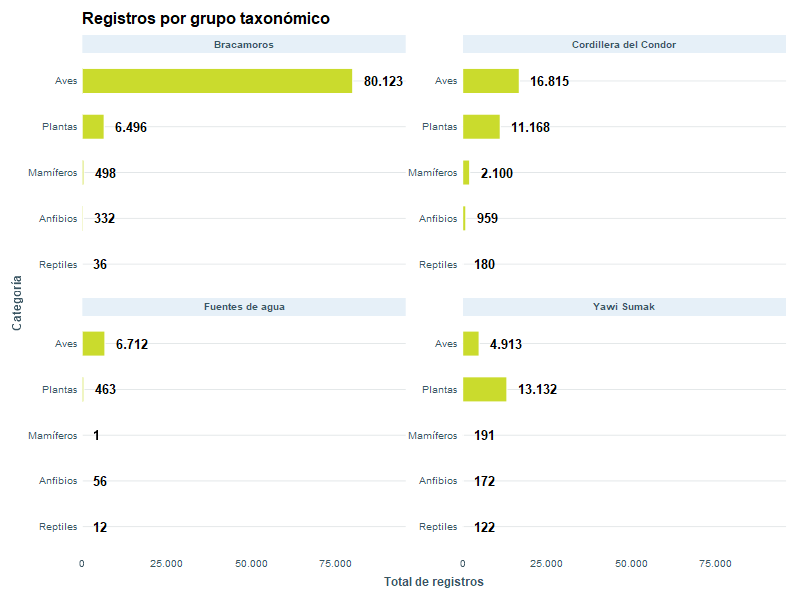

In [37]:
max_val <- max(records_by_group_acus$Total_records, na.rm = TRUE)
offset_etiqueta <- max_val * 0.04

plot_records_group_acus_2 <- ggplot(
  records_by_group_acus,
  aes(x = reorder(Group, Total_records), y = Total_records)
) +
  geom_bar(
    stat = "identity",
    width = 0.55,
    fill = pal_zch["verde_lima"],
    color = "white"
  ) +
  geom_text(
    aes(
      y = Total_records + offset_etiqueta,
      label = scales::number(Total_records, big.mark = ".", decimal.mark = ",")
    ),
    hjust = 0,
    color = "black",
    fontface = "bold",
    size = 4.5
  ) +
  coord_flip() +
  facet_wrap(~Nombre, scales = "free_y") +
  scale_y_continuous(
    labels = scales::label_number(big.mark = ".", decimal.mark = ","),
    expand = expansion(mult = c(0, 0.15))
  ) +
  labs(
    title = "Registros por grupo taxonómico",
    x = "Categoría",
    y = "Total de registros"
  ) +
  theme_zch() +
  theme(
    panel.grid.major.x = element_blank(),
    legend.position = "none",
    strip.text = element_text(face = "bold")
  )

plot_records_group_acus_2

### Species by group

In [38]:
sp_by_group_acus= recors_acus_filter %>%
  group_by(Nombre, Group)%>%
  distinct(scientificName)%>%
  summarise(Total_sp = n())%>%
  arrange(-Total_sp)
sp_by_group_acus

`summarise()` has grouped output by 'Nombre'. You can override using the
`.groups` argument.


# A tibble: 20 × 3
# Groups:   Nombre [4]
   Nombre                Group     Total_sp
   <chr>                 <chr>        <int>
 1 Yawi Sumak            Plantas       2834
 2 Cordillera del Condor Plantas       1982
 3 Bracamoros            Plantas       1326
 4 Cordillera del Condor Aves           611
 5 Bracamoros            Aves           553
 6 Yawi Sumak            Aves           419
 7 Fuentes de agua       Aves           339
 8 Fuentes de agua       Plantas        221
 9 Cordillera del Condor Anfibios       107
10 Cordillera del Condor Mamíferos       50
11 Cordillera del Condor Reptiles        45
12 Yawi Sumak            Anfibios        40
13 Bracamoros            Anfibios        38
14 Yawi Sumak            Mamíferos       30
15 Bracamoros            Mamíferos       27
16 Yawi Sumak            Reptiles        26
17 Bracamoros            Reptiles        17
18 Fuentes de agua       Anfibios        14
19 Fuentes de agua       Reptiles         6
20 Fuentes de agua       Mamíferos

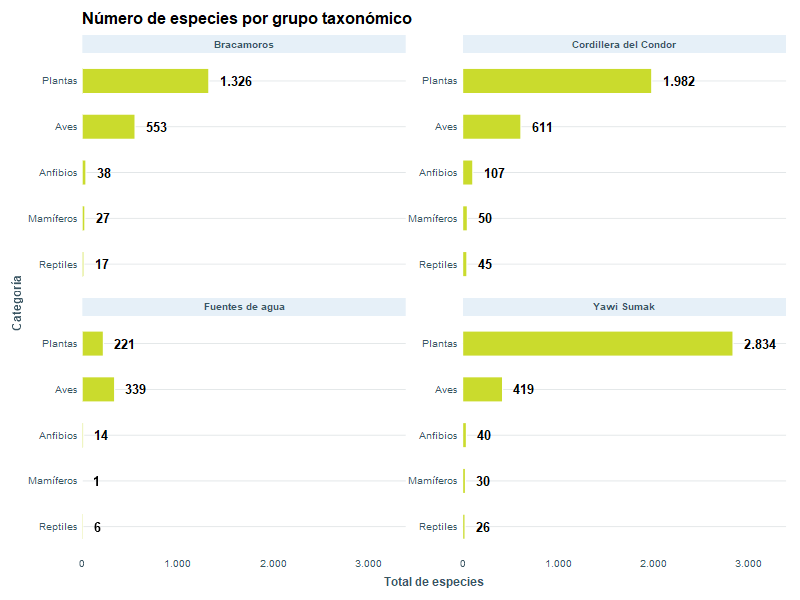

In [39]:
max_val <- max(sp_by_group_acus$Total_sp, na.rm = TRUE)
offset_etiqueta <- max_val * 0.04

plot_sp_group_acus <- ggplot(
  sp_by_group_acus,
  aes(x = reorder(Group, Total_sp), y = Total_sp)
) +
  geom_bar(
    stat = "identity",
    width = 0.55,
    fill = pal_zch["verde_lima"],
    color = "white"
  ) +
  geom_text(
    aes(
      y = Total_sp + offset_etiqueta,
      label = scales::number(Total_sp, big.mark = ".", decimal.mark = ",")
    ),
    hjust = 0,
    color = "black",
    fontface = "bold",
    size = 4.5
  ) +
  coord_flip() +
  facet_wrap(~Nombre, scales = "free_y") +
  scale_y_continuous(
    labels = scales::label_number(big.mark = ".", decimal.mark = ","),
    expand = expansion(mult = c(0, 0.15))
  ) +
  labs(
    title = "Número de especies por grupo taxonómico",
    x = "Categoría",
    y = "Total de especies"
  ) +
  theme_zch() +
  theme(
    panel.grid.major.x = element_blank(),
    legend.position = "none",
    strip.text = element_text(face = "bold")
  )

plot_sp_group_acus

In [40]:
unique(records_by_group_acus$Nombre)

[1] "Bracamoros"            "Cordillera del Condor" "Yawi Sumak"           
[4] "Fuentes de agua"      